# Exploratory Data Analysis: Macroeconomic Indicators
**Project:** SME Financial Distress & Recurrent Survival Analysis

This notebook performs a deep-dive analysis into the macroeconomic landscape of Portugal (2005-2023). These variables serve as the 'environmental' features (H1) for our survival models, capturing the systemic risks that influence SME distress and recovery.

In [21]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

# Global aesthetic configurations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

macro_path = "../data/raw/macro/"
files = [f for f in os.listdir(macro_path) if f.endswith('.csv')]

# Academic naming mapping
title_mapping = {
    'deaths_births_survivors_firms': 'Business Demography (Births vs Deaths)',
    'inflation_rate_goods_services': 'Inflation Rate (%)',
    'interest_rate_on_firm_loans_anual_mean': 'Interest Rate (SME < 1M€) (%)',
    'minmum_wage': 'National Minimum Wage (Euros)',
    'pib_by_year': 'GDP (Current Prices - M€)',
    'pib_capita': 'GDP per Capita (Euros)',
    'pib_growth': 'Real GDP Growth (%)',
    'public_debt_%_pib': 'Public Debt (% of GDP)',
    'unemployment_rate': 'Unemployment (Total Registered - N.º)'
}

print(f"Found {len(files)} macro indicators ready for analysis.")

Found 9 macro indicators ready for analysis.


## 1. Initial Data Analysis (Raw Files)

In this section, we individually analyze each raw file to identify its filter structure and granularity. 
The goal is to validate the need for surgical cleaning to obtain unique national time series.

In [22]:
for file in files:
    df_tmp = pd.read_csv(os.path.join(macro_path, file), encoding='utf-8-sig', low_memory=False)
    print(f"\n{'='*60}")
    print(f"FILE: {file}")
    print(f"{'='*60}")
    
    # 1. Show Columns
    print(f"Columns: {list(df_tmp.columns)}")
    
    # 2. Check for Duplicates per Year
    year_col = df_tmp.columns[0]
    if 'Ano' in year_col or 'Year' in year_col:
        counts = df_tmp.groupby(year_col).size()
        max_rows = counts.max()
        print(f"Max records per year: {max_rows} (Needs filtering if > 1)")
    
    # 3. Show potential filter columns (02 to 06)
    filter_cols = [c for c in df_tmp.columns if any(x in c for x in ['02.', '03.', '04.', '05.', '06.'])]
    if filter_cols:
        print("\nUnique values in filter columns:")
        for col in filter_cols:
            uniques = df_tmp[col].dropna().unique()
            print(f"  - {col}: {list(uniques[:3])}... ({len(uniques)} total)")
    
    print("\nFirst 2 rows preview:")
    display(df_tmp.head(2))


FILE: deaths_births_survivors_firms.csv
Columns: ['Year', 'Births', 'Deaths', ' 1_Year_Survivors', ' 2_Year_Survivors']
Max records per year: 1 (Needs filtering if > 1)

First 2 rows preview:


,Year,Births,Deaths,1_Year_Survivors,2_Year_Survivors
0,2004,144991,115034,NaN,NaN
1,2005,153884,138720,111577.0,NaN



FILE: inflation_rate_goods_services.csv
Columns: ['01. Ano', '02. Nome Região (Portugal)', '03. Filtro 1', '04. Filtro 2', '05. Filtro 3', '06. Escala', '07. Símbolo', '08. Valor']
Max records per year: 13 (Needs filtering if > 1)

Unique values in filter columns:
  - 02. Nome Região (Portugal): ['Portugal', 'Indicador: Taxa de inflação (%) por bens e serviços (Portugal)', 'Ultima atualização: 15.01.2025']... (4 total)
  - 03. Filtro 1: ['Acessórios para o lar, equipamento doméstico e manutenção corrente da habitação', 'Bebidas alcoólicas e tabaco', 'Bens e serviços diversos']... (13 total)
  - 04. Filtro 2: []... (0 total)
  - 05. Filtro 3: []... (0 total)
  - 06. Escala: []... (0 total)

First 2 rows preview:


,01. Ano,02. Nome Região (Portugal),03. Filtro 1,04. Filtro 2,05. Filtro 3,06. Escala,07. Símbolo,08. Valor
0,1960.0,Portugal,"Acessórios para o lar, equipamento doméstico e...",NaN,NaN,NaN,NaN,1.93
1,1960.0,Portugal,Bebidas alcoólicas e tabaco,NaN,NaN,NaN,NaN,0.12



FILE: interest_rate_on_firm_loans_anual_mean.csv
Columns: ['01. Ano', '02. Nome Região (Portugal)', '03. Filtro 1', '04. Filtro 2', '05. Filtro 3', '06. Escala', '07. Símbolo', '08. Valor']
Max records per year: 3 (Needs filtering if > 1)

Unique values in filter columns:
  - 02. Nome Região (Portugal): ['Portugal', 'Indicador: Taxas de juro sobre novas operações de empréstimos (média anual) a empresas por escalão de crédito', 'Ultima atualização: 07.02.2025 08:20:03']... (4 total)
  - 03. Filtro 1: ['Até 1 milhão de euros (inclusive)', 'Mais de 1 milhão de euros', 'Total']... (3 total)
  - 04. Filtro 2: []... (0 total)
  - 05. Filtro 3: []... (0 total)
  - 06. Escala: []... (0 total)

First 2 rows preview:


...

,01. Ano,02. Nome País (Europa),03. Nome Região (Portugal),04. Filtro 1,05. Filtro 2,06. Filtro 3,07. Escala,08. Símbolo,09. Valor
0,1960.0,NaN,Portugal,NaN,NaN,NaN,NaN,NaN,3.8
1,1961.0,NaN,Portugal,NaN,NaN,NaN,NaN,NaN,2.7



FILE: public_debt_%_pib.csv
Columns: ['01. Ano', '02. Nome País (Europa)', '03. Nome Região (Portugal)', '04. Filtro 1', '05. Filtro 2', '06. Filtro 3', '07. Escala', '08. Símbolo', '09. Valor']
Max records per year: 28 (Needs filtering if > 1)

Unique values in filter columns:
  - 02. Nome País (Europa): ['Alemanha', 'Áustria', 'Bélgica']... (30 total)
  - 03. Nome Região (Portugal): ['Portugal']... (1 total)
  - 04. Filtro 1: []... (0 total)
  - 05. Filtro 2: []... (0 total)
  - 06. Filtro 3: []... (0 total)

First 2 rows preview:


,01. Ano,02. Nome País (Europa),03. Nome Região (Portugal),04. Filtro 1,05. Filtro 2,06. Filtro 3,07. Escala,08. Símbolo,09. Valor
0,1960.0,NaN,Portugal,NaN,NaN,NaN,NaN,NaN,15.1
1,1961.0,NaN,Portugal,NaN,NaN,NaN,NaN,NaN,15.7



FILE: unemployment_rate.csv
Columns: ['01. Ano', '02. Nome País (Europa)', '04. Filtro 1', '05. Filtro 2', '06. Filtro 3', '09. Valor']
Max records per year: 1 (Needs filtering if > 1)

Unique values in filter columns:
  - 02. Nome País (Europa): ['Portugal']... (1 total)
  - 04. Filtro 1: ['Total']... (1 total)
  - 05. Filtro 2: ['Total']... (1 total)
  - 06. Filtro 3: ['Total']... (1 total)

First 2 rows preview:


,01. Ano,02. Nome País (Europa),04. Filtro 1,05. Filtro 2,06. Filtro 3,09. Valor
0,2024,Portugal,Total,Total,Total,335665
1,2023,Portugal,Total,Total,Total,317659


## 2. Automated Cleaning & Standardization

Based on the previous analysis, the `clean_macro_df` function applies necessary filters (e.g., 'Portugal', 'Total') to consolidate the data into a structure usable by Machine Learning models.

In [23]:
def clean_macro_df(file_name, df):
    key = file_name.replace('.csv', '')
    
    if 'deaths_births' in file_name:
        df = df[['Year', 'Births', 'Deaths']].copy()
        df.columns = ['year', 'firm_births', 'firm_deaths']
        return df.set_index('year')
    
    year_col = df.columns[0]
    value_col = [c for c in df.columns if 'Valor' in c][0]
    
    # Surgical Filtering Logic (Handles 6-column and 9-column formats)
    if 'unemployment_rate' in file_name:
        if len(df.columns) > 2:
            df = df[(df.iloc[:, 1] == 'Portugal')]
            for i in range(2, len(df.columns) - 1):
                if 'Total' in df.iloc[:, i].unique():
                    df = df[df.iloc[:, i] == 'Total']
        
    elif 'inflation_rate' in file_name:
        df = df[df.iloc[:, 2] == 'Total']
    elif 'interest_rate' in file_name:
        df = df[df.iloc[:, 2].str.contains('Até 1 milhão', na=False, case=False)]
    elif 'minmum_wage' in file_name:
        df = df[df.iloc[:, 2].str.contains('Portugal continental', na=False, case=False)]
    elif 'pib_' in file_name or 'public_debt' in file_name:
        mask = df.iloc[:, 1:3].apply(lambda x: x.astype(str).str.contains('Portugal', na=False)).any(axis=1)
        df = df[mask]

    new_df = df[[year_col, value_col]].copy()
    new_df.columns = ['year', key]
    new_df['year'] = pd.to_numeric(new_df['year'], errors='coerce')
    new_df[key] = pd.to_numeric(new_df[key], errors='coerce')
    
    return new_df.dropna().sort_values('year').groupby('year').mean()

cleaned_dfs = []
for file in files:
    df_raw = pd.read_csv(os.path.join(macro_path, file), encoding='utf-8-sig', low_memory=False)
    df_clean = clean_macro_df(file, df_raw)
    cleaned_dfs.append(df_clean)
    print(f"Processed: {file} | Time Range: {df_clean.index.min()} - {df_clean.index.max()}")

Processed: deaths_births_survivors_firms.csv | Time Range: 2004 - 2022
Processed: inflation_rate_goods_services.csv | Time Range: 1960.0 - 2024.0
Processed: interest_rate_on_firm_loans_anual_mean.csv | Time Range: 2003.0 - 2024.0
Processed: minmum_wage.csv | Time Range: 1974.0 - 2025.0
Processed: pib_by_year.csv | Time Range: 1960.0 - 2024.0
Processed: pib_capita.csv | Time Range: 1960.0 - 2024.0
Processed: pib_growth.csv | Time Range: 1960.0 - 2024.0
Processed: public_debt_%_pib.csv | Time Range: 1960.0 - 2024.0
Processed: unemployment_rate.csv | Time Range: 1997 - 2024


## 3. Time Series Visualization
Validating the data against economic shock periods: the **Troika Bailout (2011-2014)** and **COVID-19 (2020-2021)**.

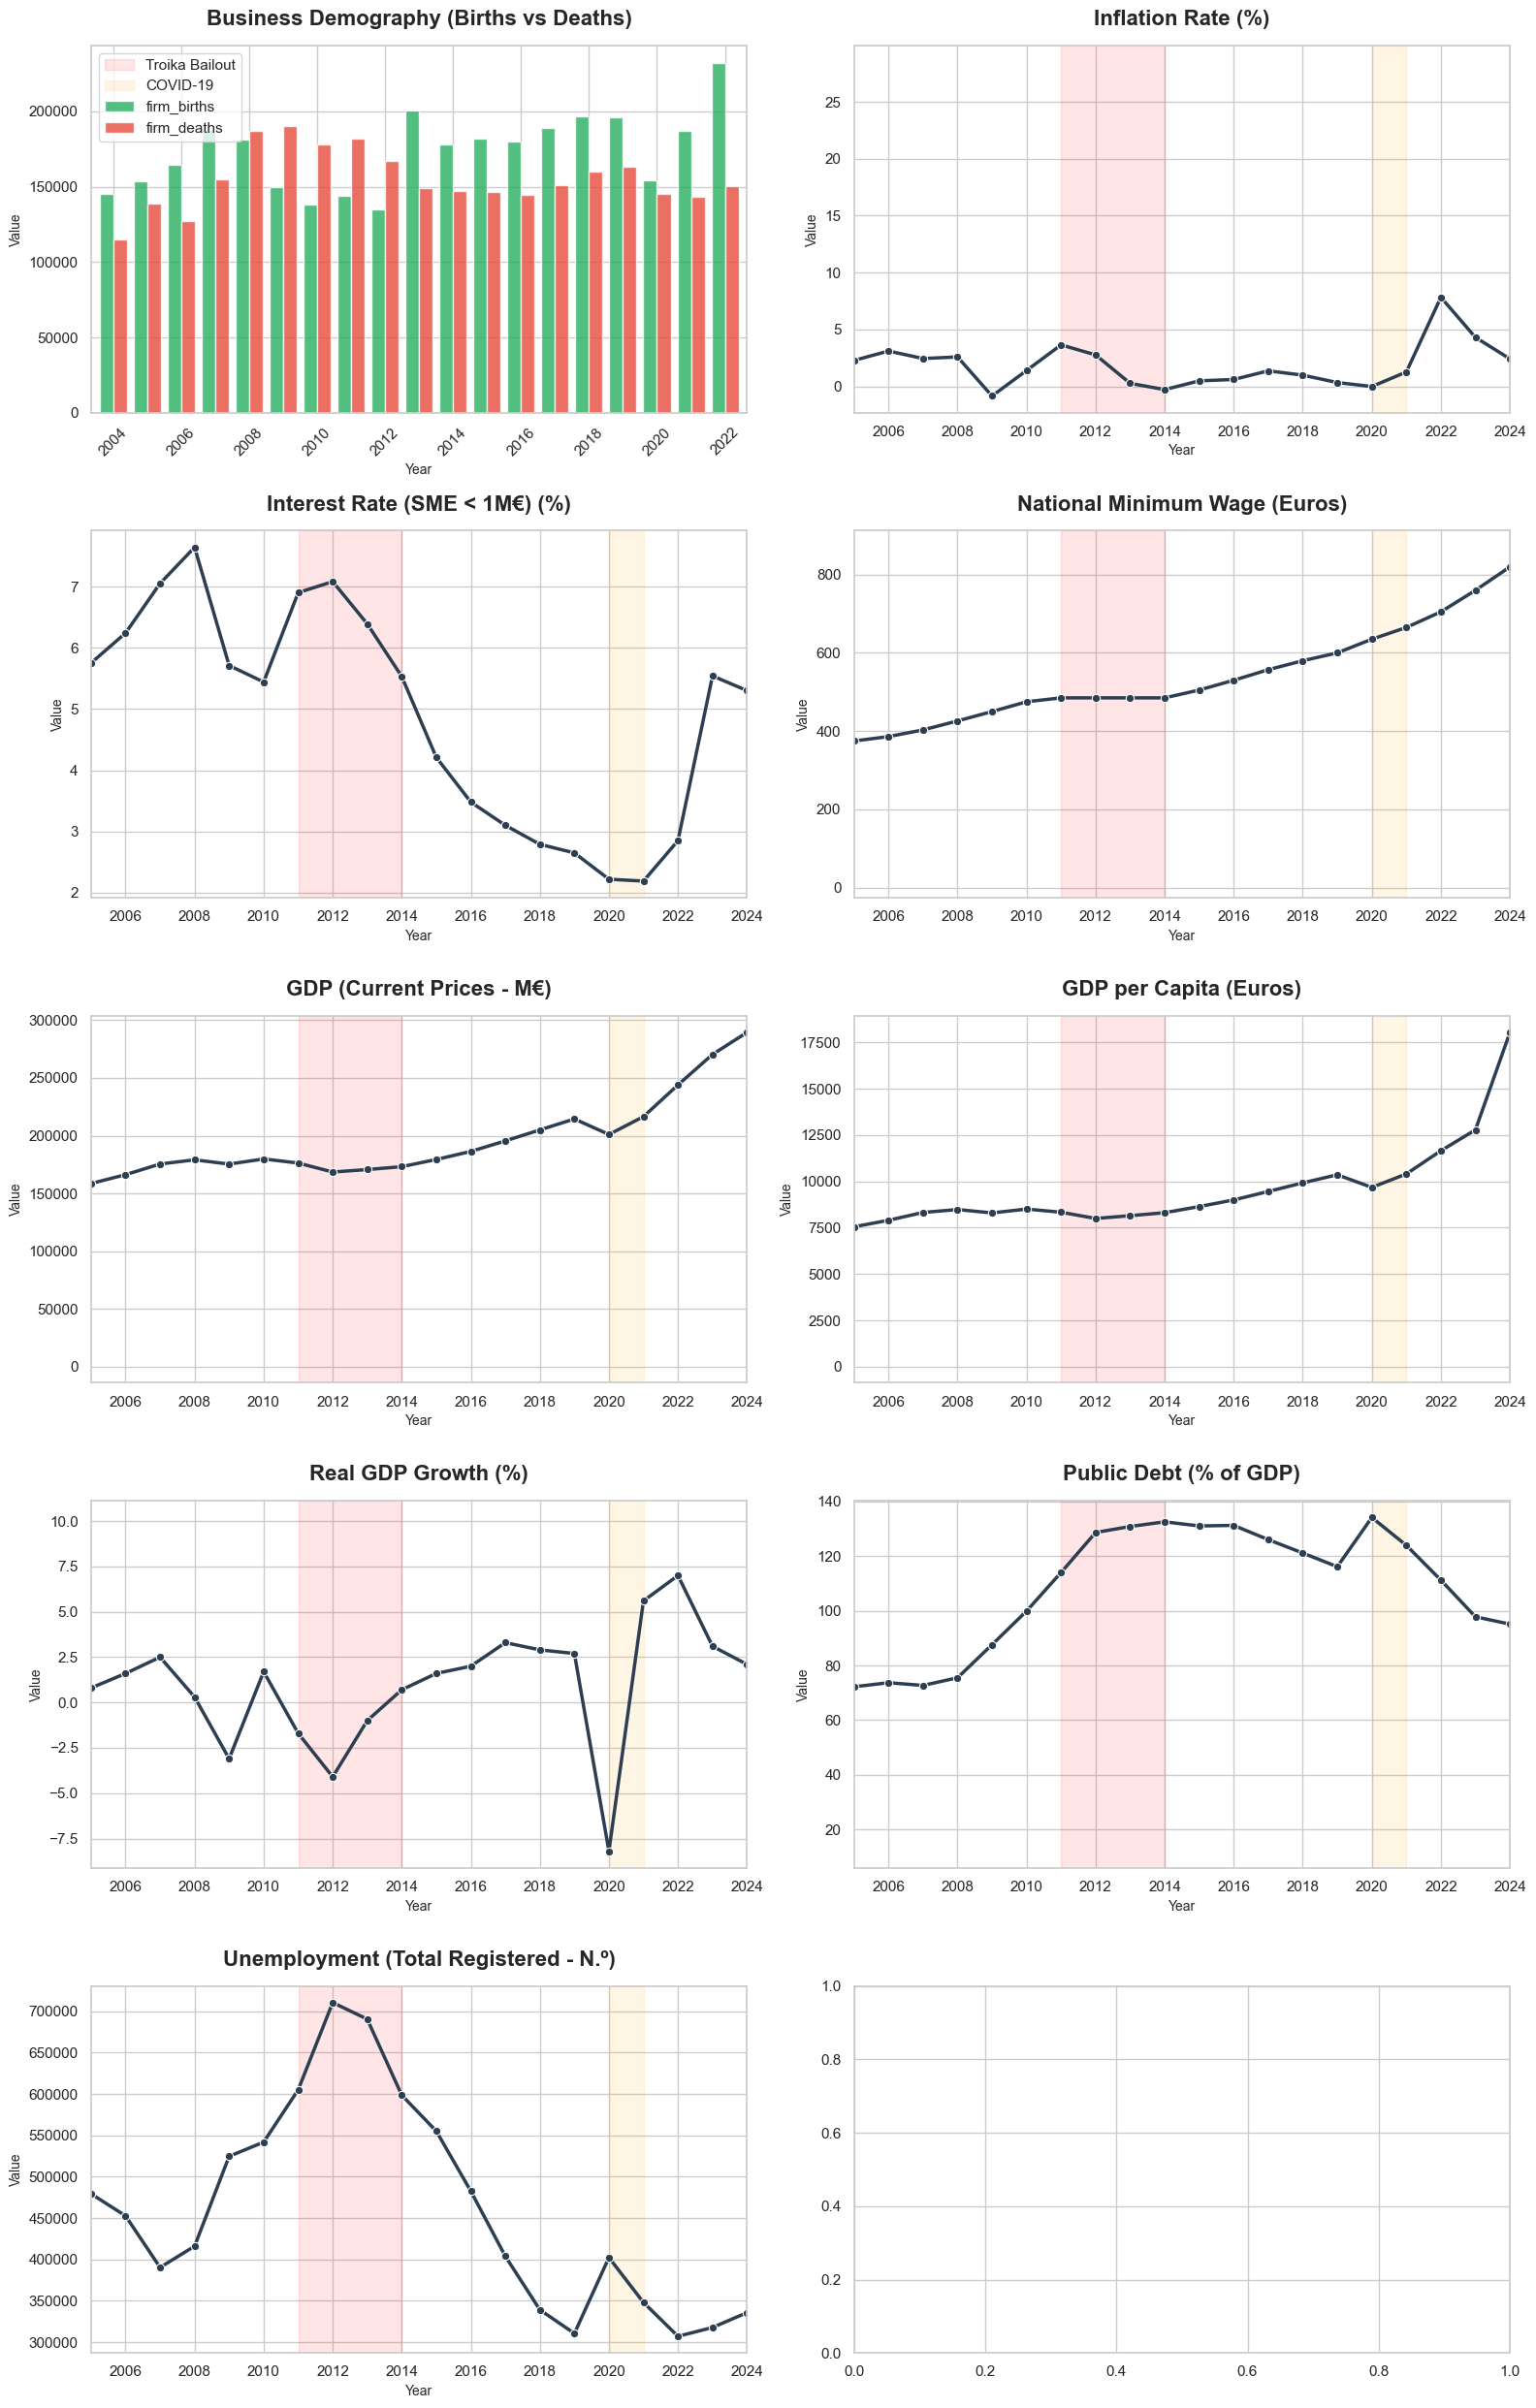

In [24]:
n_indicators = len(cleaned_dfs)
fig, axes = plt.subplots(nrows=(n_indicators + 1) // 2, ncols=2, figsize=(16, 5 * ((n_indicators + 1) // 2)))
axes = axes.flatten()

crises = [
    {'range': (2011, 2014), 'label': 'Troika Bailout', 'color': 'red'},
    {'range': (2020, 2021), 'label': 'COVID-19', 'color': 'orange'}
]

for i, df in enumerate(cleaned_dfs):
    ax = axes[i]
    key = df.columns[0] if len(df.columns) == 1 else "deaths_births_survivors_firms"
    pretty_title = title_mapping.get(key, key)
    
    if key == "deaths_births_survivors_firms":
        df.plot(kind='bar', ax=ax, width=0.8, color=['#27ae60', '#e74c3c'], alpha=0.8)
        ax.set_xticklabels(df.index.astype(int), rotation=45)
    else:
        sns.lineplot(data=df, x=df.index, y=key, ax=ax, marker='o', linewidth=2.5, color='#2c3e50')
    
    for crisis in crises:
        ax.axvspan(crisis['range'][0], crisis['range'][1], color=crisis['color'], alpha=0.1, 
                   label=crisis['label'] if i == 0 else "")
    
    ax.set_title(pretty_title, fontweight='bold', pad=15)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Value", fontsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    if key != "deaths_births_survivors_firms":
        ax.set_xlim(2005, 2024)
    
    if i == 0: ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

## 4. Statistical Analysis & Correlation Matrices

To understand the relationship between indicators, we use two types of correlation:
1. **Pearson Correlation:** Measures linear relationships. It is sensitive to extreme values (outliers) like the 2020 economic shock.
2. **Spearman Correlation:** Measures monotonic relationships using ranks. It is much more robust to outliers and non-linear trends.

Comparing both helps identify if the correlations are consistent or distorted by specific crisis years.

--- Descriptive Statistics (2005-2023) ---


,count,mean,std,min,25%,50%,75%,max
firm_births,18.0,175060.444444,25413.182990,134757.00,153984.7500,180621.500,188528.0000,232173.000000
firm_deaths,18.0,157017.611111,17657.833513,127482.00,145446.5000,150713.000,166264.2500,190433.000000
inflation_rate_goods_services,20.0,1.851000,1.970955,-0.84,0.4525,1.385,2.6350,7.830000
interest_rate_on_firm_loans_anual_mean,20.0,4.903000,1.799281,2.19,3.0375,5.485,6.2775,7.640000
minmum_wage,21.0,556.266667,140.729032,374.70,475.0000,505.000,635.0000,870.000000
pib_by_year,20.0,196271.470000,35372.352687,158552.70,174858.9750,179626.550,207370.6750,289428.000000
pib_capita,20.0,9588.986667,2395.353825,7549.05,8307.6500,8573.425,10029.7500,18041.333333
pib_growth,20.0,0.990000,3.390373,-8.20,-0.0250,1.650,2.7500,7.000000
public_debt_%_pib,20.0,108.750000,22.541903,72.20,93.2250,115.050,129.1500,134.100000
unemployment_rate,20.0,460563.900000,125461.694334,307005.00,345728.0000,434328.000,545171.7500,710652.000000


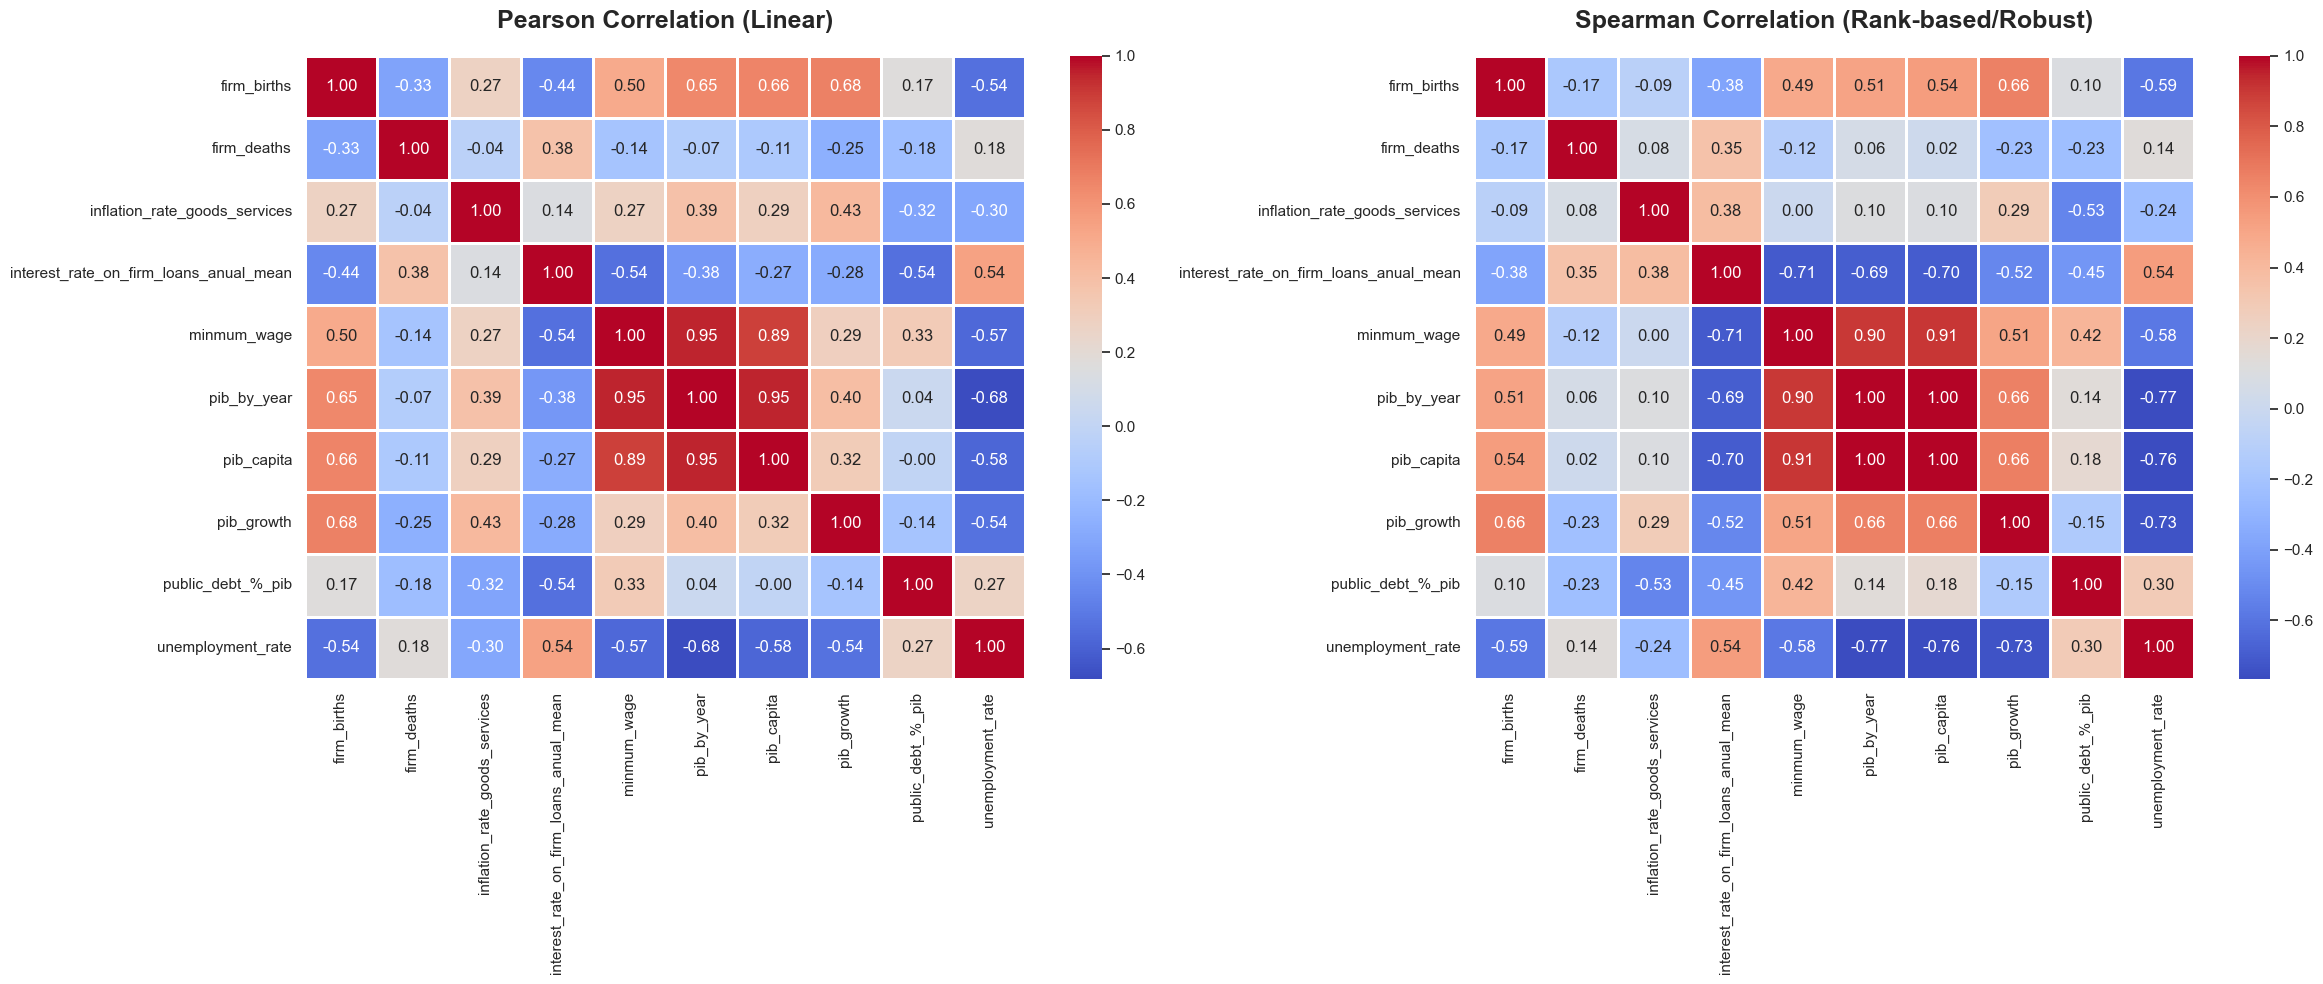

In [25]:
macro_final = pd.concat(cleaned_dfs, axis=1).sort_index().loc[2005:]

print("--- Descriptive Statistics (2005-2023) ---")
display(macro_final.describe().T)

# Plotting both correlations side by side for direct comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Pearson
pearson_corr = macro_final.corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, ax=ax1)
ax1.set_title("Pearson Correlation (Linear)", fontsize=18, fontweight='bold', pad=20)

# Spearman
spearman_corr = macro_final.corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, ax=ax2)
ax2.set_title("Spearman Correlation (Rank-based/Robust)", fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### Correlation Insights: Linear vs. Structural Dependencies

The comparison between **Pearson (linear)** and **Spearman (rank-based)** correlations reveals critical insights into the Portuguese macroeconomic environment. For instance, the relationship between **GDP per Capita** and **Interest Rates for SME Loans** shows a dramatic discrepancy: a weak Pearson correlation (**-0.27**) contrasted with a strong Spearman correlation (**-0.70**). 

This divergence indicates that while a structural, long-term inverse relationship exists (as national wealth increases, credit risk and interest rates typically decrease), the linear strength is heavily distorted by exogenous shocks and policy interventions. Specifically, the **2011-2014 Sovereign Debt Crisis** followed a traditional linear path (rates spiked as GDP fell), while the **2020 COVID-19 shock** decoupled this relationship (GDP plummeted, but rates remained low due to aggressive ECB intervention). These non-linear dynamics strongly justify the use of advanced survival models like **Random Survival Forests (RSF)** and **DeepHit**, which are better equipped than traditional Cox models to capture such complex, non-linear environmental signals in business distress prediction.

## 5. Consolidation & Export
Exporting clean data to the 'interim' layer for subsequent merging with firm-level data (SABI).

In [26]:
output_file = '../data/interim/macro_consolidated.csv'
os.makedirs('../data/interim', exist_ok=True)
macro_final.to_csv(output_file)
print(f"\nSUCCESS: {macro_final.shape[1]} indicators consolidated for {len(macro_final)} years.")
print(f"File saved at: {output_file}")


SUCCESS: 10 indicators consolidated for 21 years.
File saved at: ../data/interim/macro_consolidated.csv
